In this notebook, IMU data collected during the UAV flight are visualized.
There are two UAV flight data collected outdoor:
    - log0001: 76 seconds;
    - log0002: 70 seconds;
and one flight data collected indoor:
    - log0003: 48 seconds.

Since four/five IMUs are embedded on the VOXL flight, where two IMUs are attached to the VOXL side and the other two are placed on the PX4 flight core, IMUs from the both sides are visualized separately.
Moreover, since indoor flight does not consist of PX4 data, two IMU data are visualized.

In [1]:
import os
import sys
import yaml
from tqdm import tqdm
sys.path.append('/app/src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.base_filter import BaseFilter
from data_loader import UAV_DataLoader, DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum, IMU_Type
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm
from scipy.signal import medfilt
%matplotlib inline
np.random.seed(777)

In [2]:
def get_quaternion_from_euler_angle(angle):
    roll, pitch, yaw = angle
    cr = np.cos(roll * 0.5)
    sr = np.sin(roll * 0.5)
    cp = np.cos(pitch * 0.5)
    sp = np.sin(pitch * 0.5)
    cy = np.cos(yaw * 0.5)
    sy = np.sin(yaw * 0.5)

    w = cr * cp * cy + sr * sp * sy
    x = sr * cp * cy - cr * sp * sy
    y = cr * sp * cy + sr * cp * sy
    z = cr * cp * sy - sr * sp * cy

    return np.array([w, x, y, z])

def plot_imu(imu0_df, imu1_df, title="IMU data"):
    fig, (ax1, ax2) = plt.subplots(2, 3, figsize=(16, 8))
    acc_titles = ["AX(m/s2)", "AY(m/s2)", "AZ(m/s2)"]
    gyr_titles = ["GX(rad/s)", "GY(rad/s)", "GZ(rad/s)"]
    fig.suptitle(title, fontsize=24)
    
    for i in range(0, 3):
        ax1[i].title.set_text(acc_titles[i])
        ax2[i].title.set_text(gyr_titles[i])
        acc_columns = loader.voxl_imu0_df.columns[1:4]
        gyr_columns = loader.voxl_imu0_df.columns[4:7]
        
        voxl_imu0_val = (imu0_df[acc_columns].values[:, i] -\
                     loader.imu_config[IMU_Type.IMU0.value]['accelerometer']['offset'][i]) * loader.imu_config[IMU_Type.IMU0.value]['accelerometer']['scale'][i]
        ax1[i].plot(voxl_imu0_val, color="red", lw=0.5, label="VOXL IMU0")
        
        imu_data_filtered = medfilt(voxl_imu0_val, kernel_size=25)
        ax1[i].plot(imu_data_filtered, color="green", lw=0.5, label="VOXL filtered IMU0")
    
        
        voxl_imu1_val = (imu1_df[acc_columns].values[:, i] -\
                     loader.imu_config[IMU_Type.IMU1.value]['accelerometer']['offset'][i]) * loader.imu_config[IMU_Type.IMU1.value]['accelerometer']['scale'][i]
        ax1[i].plot(voxl_imu1_val, color="blue", lw=0.5, label="VOXL IMU1")
    
    
        
        voxl_imu0_val = (imu0_df[gyr_columns].values[:, i] -\
                     loader.imu_config[IMU_Type.IMU0.value]['gyroscope']['offset'][i])
        ax2[i].plot(voxl_imu0_val, color="red", lw=0.5, label="VOXL IMU0")
        
        imu_data_filtered = medfilt(voxl_imu0_val, kernel_size=25)
        ax2[i].plot(imu_data_filtered, color="green", lw=0.5, label="VOXL filtered IMU0")
    
        
        voxl_imu1_val = (imu1_df[gyr_columns].values[:, i] -\
                     loader.imu_config[IMU_Type.IMU1.value]['gyroscope']['offset'][i])
        ax2[i].plot(voxl_imu1_val, color="blue", lw=0.5, label="VOXL IMU1")
    
        
        # axs[i].plot(kitti_dataloader.IMU_acc_with_noise[:, i], lw=1, color="red")
        ax1[i].grid()
        ax1[i].legend()
        ax2[i].grid()
        ax2[i].legend()

In [3]:
root_path = "../../../../data"

# Outdoor (log0001)

In [10]:
loader = UAV_DataLoader(
    root_path=root_path, 
    sequence_nr="log0001", 
    imu_config_filepath="/app/src/data_Loader/imu_config.yaml",
    is_debugging=True
)

VO estimate data not found.
UWB position data not found.


[PX4 IMU0] Sampling rate: 280441.68Hz
[PX4 IMU1] Sampling rate: 280512.72Hz
[PX4 GPS] Sampling rate: 8030.68Hz
[PX4 VO] Sampling rate: 30019.46Hz
[PX4 Vehicle Odom] Sampling rate: 100218.32Hz
[PX4 IMU0 bias] Sampling rate: 4417.47Hz
[PX4 IMU1 bias] Sampling rate: 4846.96Hz
[] Sampling rate: 284904.99Hz
[] Sampling rate: 284850.41Hz
[VOXL IMU0] Sampling rate: 1009.32Hz
[VOXL IMU1] Sampling rate: 1132.28Hz
[VOXL QVIO] Sampling rate: 30.02Hz
[VOXL stereo] Sampling rate: 9.8Hz


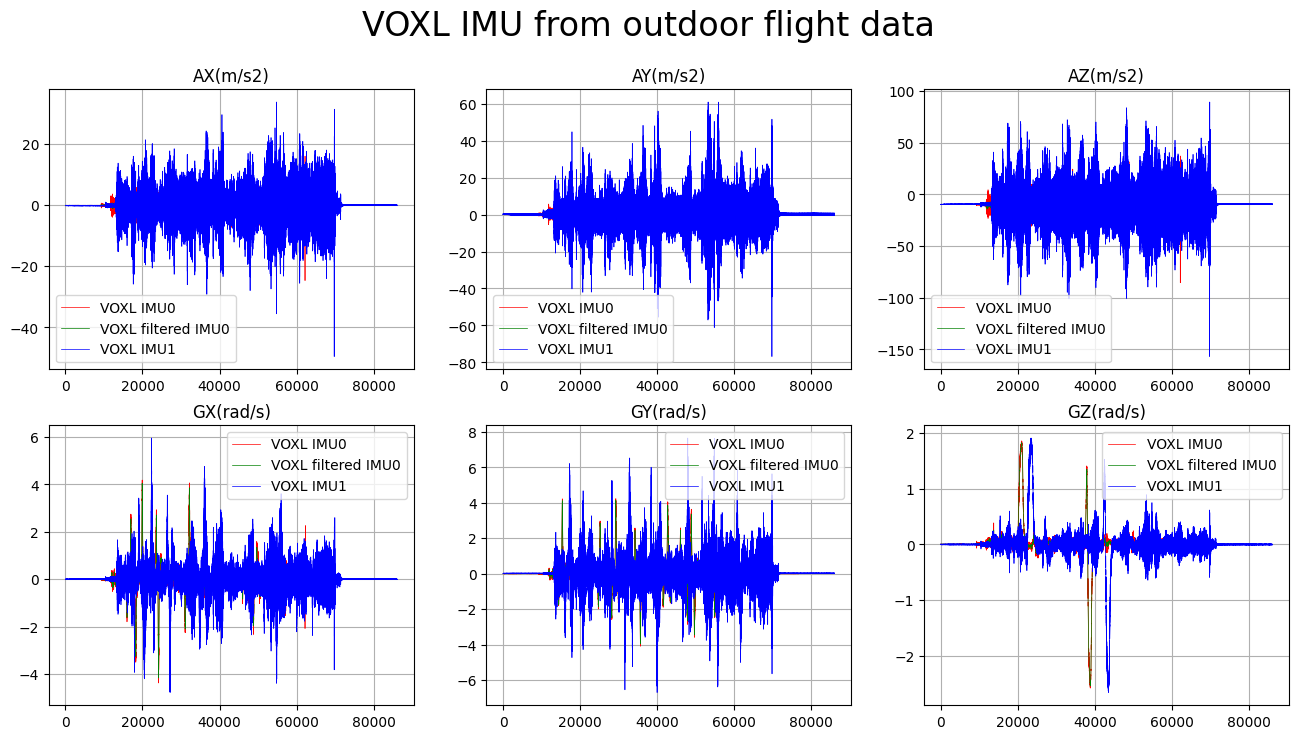

In [11]:
plot_imu(imu0_df=loader.voxl_imu0_df, imu1_df=loader.voxl_imu1_df, title="VOXL IMU from outdoor flight data")

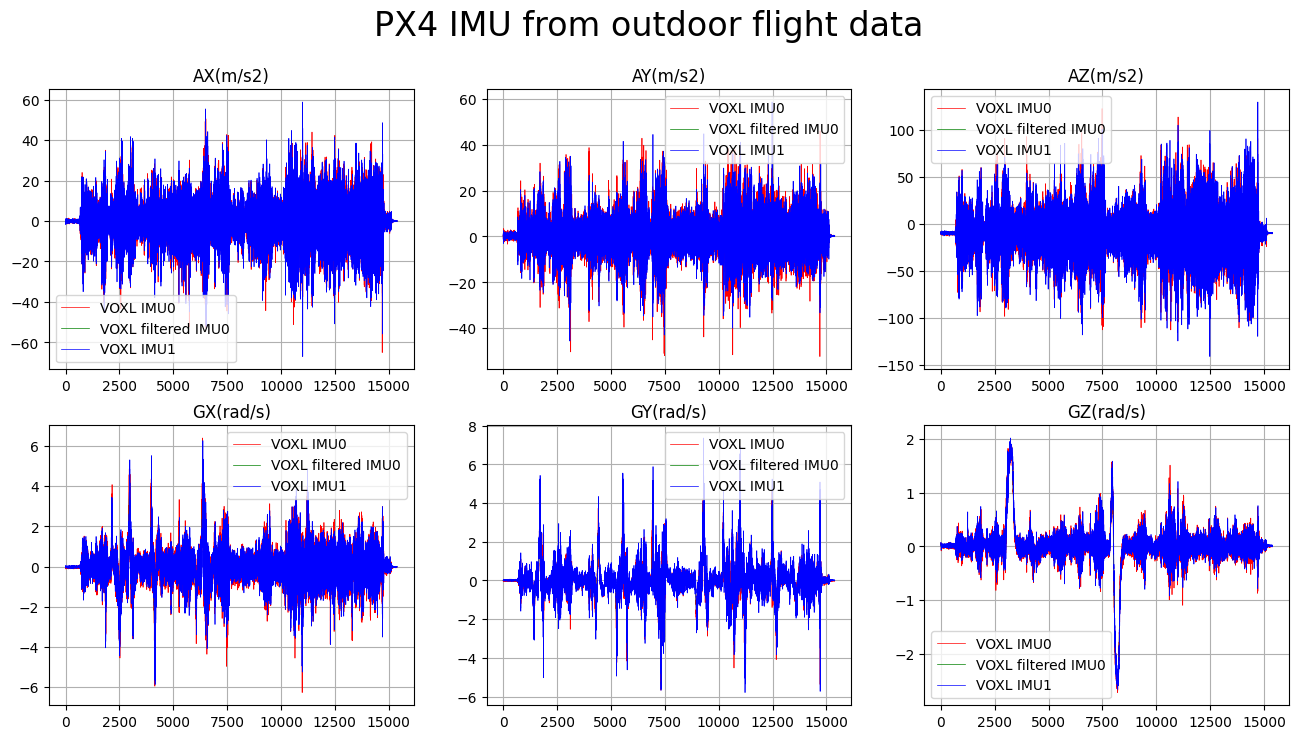

In [12]:
plot_imu(imu0_df=loader.px4_imu0_df, imu1_df=loader.px4_imu1_df, title="PX4 IMU from outdoor flight data")

# Outdoor (log0002)

In [13]:
loader = UAV_DataLoader(
    root_path=root_path, 
    sequence_nr="log0002", 
    imu_config_filepath="/app/src/data_Loader/imu_config.yaml",
    is_debugging=True
)

[PX4 IMU0] Sampling rate: 281087.27Hz
[PX4 IMU1] Sampling rate: 280242.45Hz
[PX4 GPS] Sampling rate: 8013.46Hz
[PX4 VO] Sampling rate: 30013.41Hz
[PX4 Vehicle Odom] Sampling rate: 99871.26Hz
[PX4 IMU0 bias] Sampling rate: 5729.61Hz
[PX4 IMU1 bias] Sampling rate: 5915.47Hz
[] Sampling rate: 284854.08Hz
[] Sampling rate: 284793.88Hz
[VOXL IMU0] Sampling rate: 1009.4Hz
[VOXL IMU1] Sampling rate: 1132.34Hz


VO estimate data not found.
UWB position data not found.


[VOXL QVIO] Sampling rate: 30.02Hz
[VOXL stereo] Sampling rate: 9.93Hz


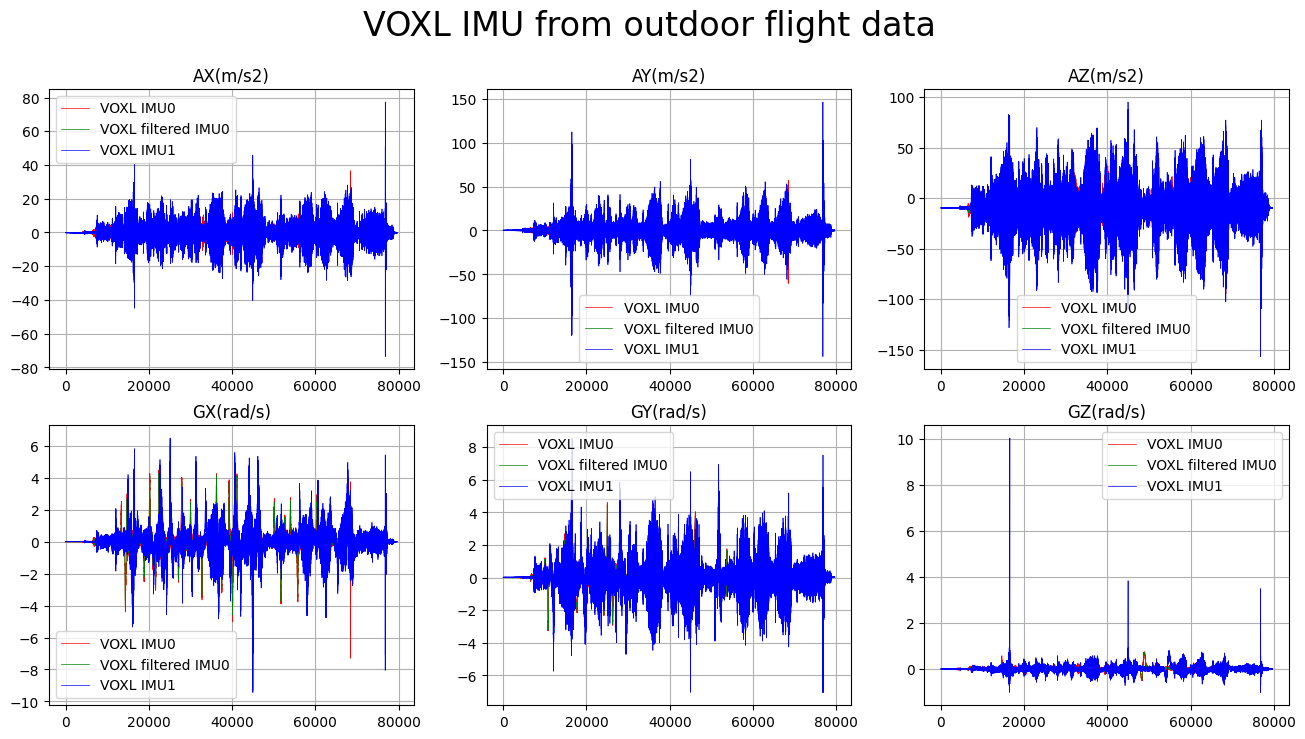

In [14]:
plot_imu(imu0_df=loader.voxl_imu0_df, imu1_df=loader.voxl_imu1_df, title="VOXL IMU from outdoor flight data")

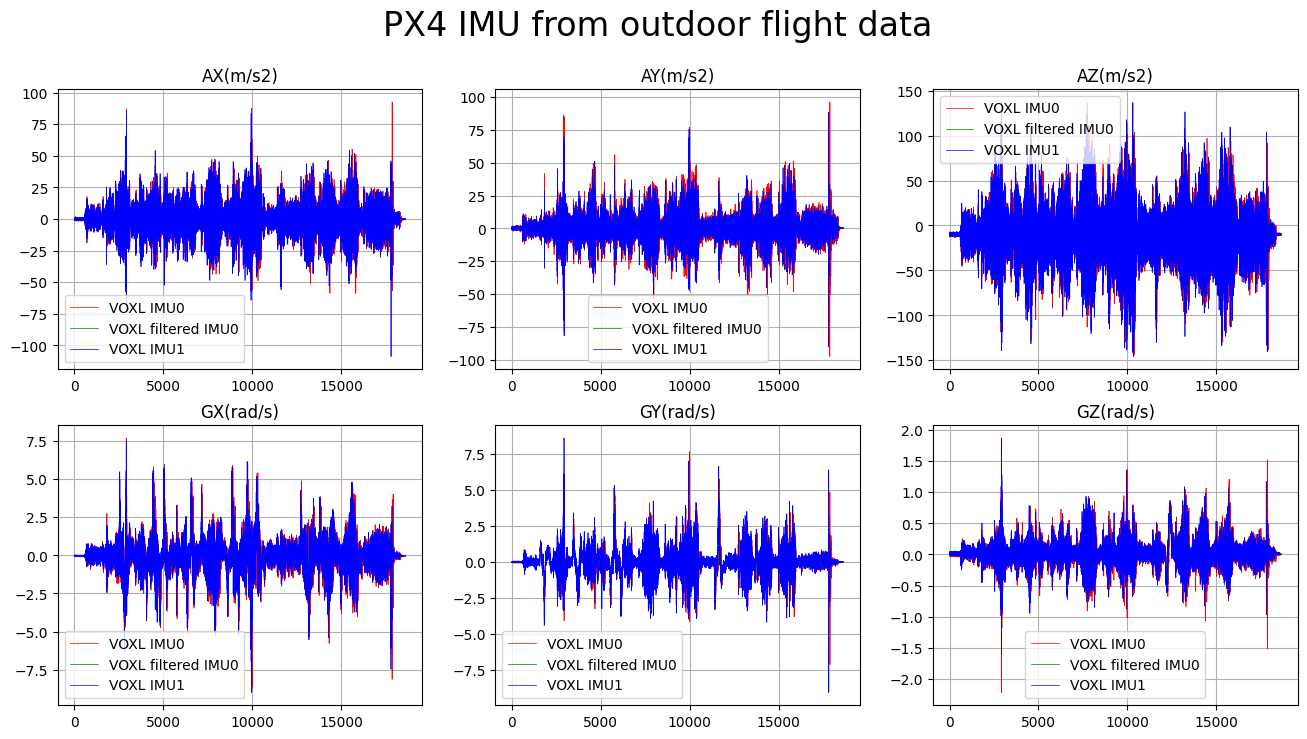

In [15]:
plot_imu(imu0_df=loader.px4_imu0_df, imu1_df=loader.px4_imu1_df, title="PX4 IMU from outdoor flight data")

# Indoor (log0003)

In [16]:
loader = UAV_DataLoader(
    root_path=root_path, 
    sequence_nr="log0003", 
    imu_config_filepath="/app/src/data_Loader/imu_config.yaml",
    is_debugging=True
)

VO estimate data not found.
UWB position data not found.


[VOXL IMU0] Sampling rate: 1009.24Hz
[VOXL IMU1] Sampling rate: 1132.15Hz
[VOXL QVIO] Sampling rate: 30.03Hz
[VOXL stereo] Sampling rate: 9.8Hz


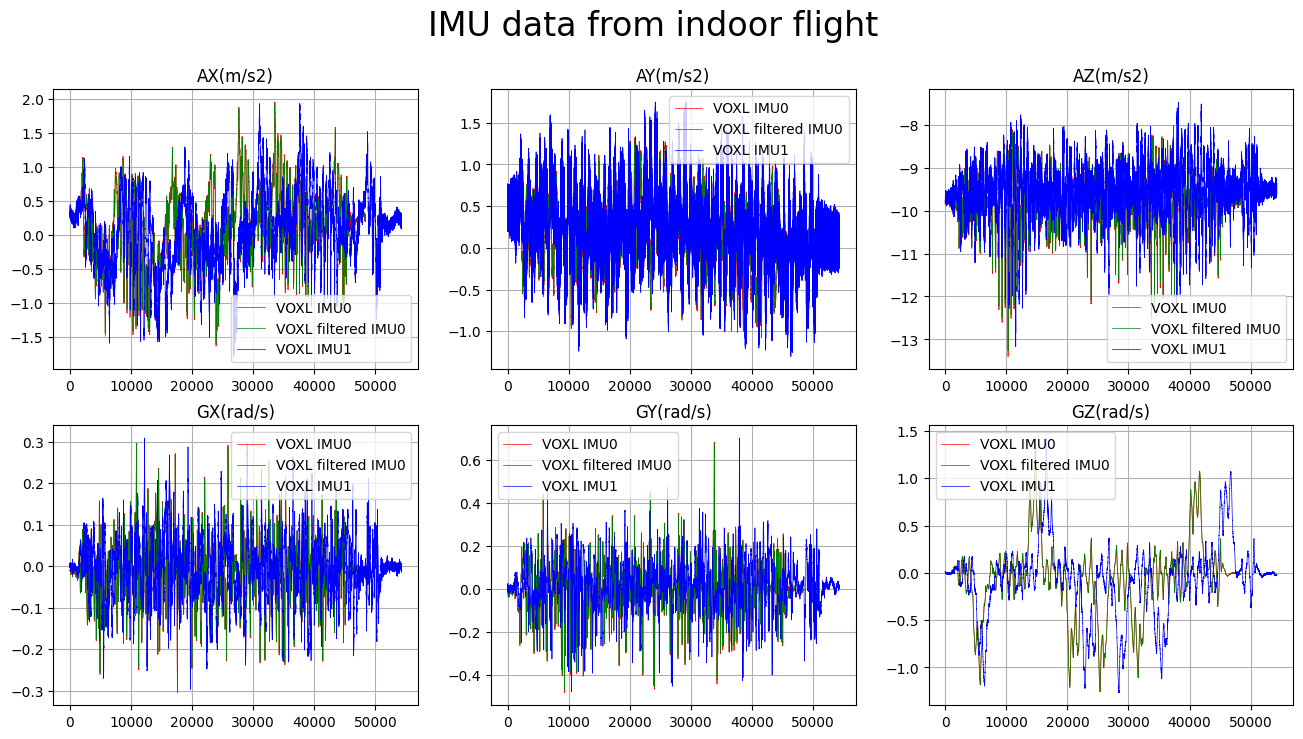

In [17]:
plot_imu(imu0_df=loader.voxl_imu0_df, imu1_df=loader.voxl_imu1_df, title="IMU data from indoor flight")